# Week-12

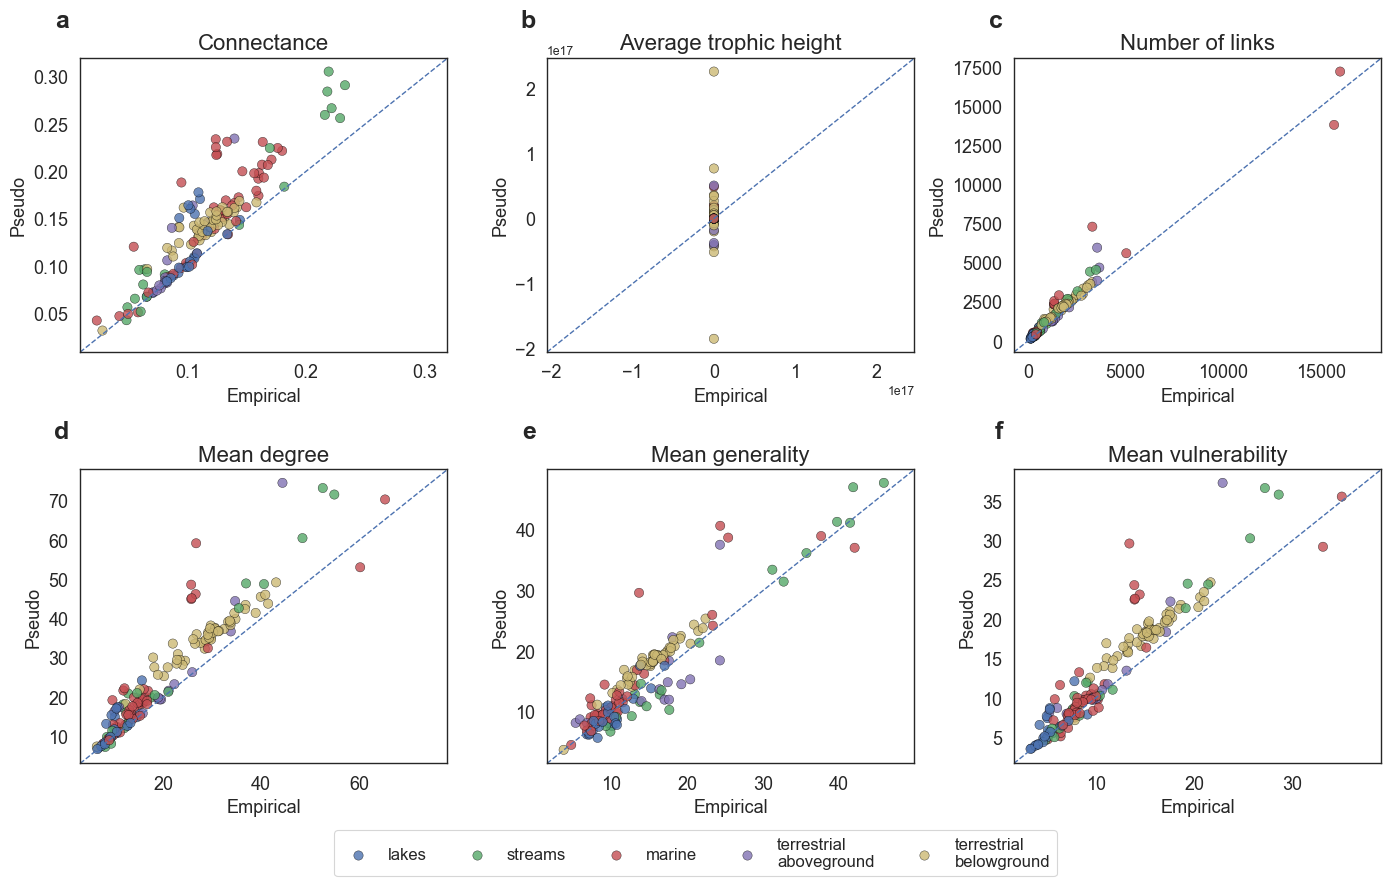

In [1]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white")

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

NODES_THRESHOLD = 40
AGGREGATE_PER_FOODWEB = True  # recommended: average repeated experiments per food web

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_palette = {
    "lakes": "#4C72B0",
    "streams": "#55A868",
    "marine": "#C44E52",
    "terrestrial aboveground": "#8172B3",
    "terrestrial belowground": "#CCB974",
}

ecosystem_labels = {
    "lakes": "lakes",
    "streams": "streams",
    "marine": "marine",
    "terrestrial aboveground": "terrestrial\naboveground",
    "terrestrial belowground": "terrestrial\nbelowground",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

# ============================================================
# HELPERS
# ============================================================
def extract_foodweb_name(filepath: str) -> str:
    """
    Extract foodweb name from:
    '.../XYZ_results_random_wlnm_dir_neg.csv' -> 'XYZ'
    """
    name = Path(filepath).name
    return name.split("_results_")[0]

def find_col(df: pd.DataFrame, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def load_all_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / "*_results_*.csv")))
    if not files:
        raise FileNotFoundError(f"No results CSVs found in: {results_dir}")

    dfs = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
            df["Foodweb"] = extract_foodweb_name(fp)
            df["SourceFile"] = Path(fp).name
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Skipping {fp}: {e}")

    if not dfs:
        raise RuntimeError("No readable result CSVs were loaded.")

    out = pd.concat(dfs, ignore_index=True)
    return out

def load_ecosystem_metadata(ecosystem_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(ecosystem_csv)

    foodweb_col = find_col(meta, ["Foodweb", "foodweb"])
    eco_col = find_col(meta, ["Ecosystem", "ecosystem", "EcosystemType", "ecosystem_type"])
    nodes_col = find_col(meta, ["Nodes", "nodes"])

    meta = meta.rename(columns={
        foodweb_col: "Foodweb",
        eco_col: "Ecosystem",
        nodes_col: "Nodes"
    })

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["Ecosystem"] = meta["Ecosystem"].astype(str)
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

    return meta[["Foodweb", "Ecosystem", "Nodes", "FW_KEY"]].drop_duplicates()

def safe_numeric_filter(df: pd.DataFrame) -> pd.DataFrame:
    # Keep only rows with valid core config fields if present
    needed = ["K", "TrainRatio"]
    for c in needed:
        if c in df.columns:
            df = df[pd.notna(df[c])]
    return df

def aggregate_foodweb_runs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate repeated experiments per food web.
    Empirical values are constant per web, pseudo/TSS/TPR may vary by run.
    We average all numeric columns per food web.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    grouped = df.groupby("Foodweb", as_index=False)[numeric_cols].mean()

    # Recover ecosystem
    eco_map = df[["Foodweb", "Ecosystem"]].drop_duplicates()
    grouped = grouped.merge(eco_map, on="Foodweb", how="left")

    # Reorder
    cols = ["Foodweb", "Ecosystem"] + [c for c in grouped.columns if c not in ("Foodweb", "Ecosystem")]
    grouped = grouped[cols]
    return grouped

def add_delta_columns(df: pd.DataFrame) -> pd.DataFrame:
    pairs = [
        ("Links", "EmpiricalLinks", "PseudoLinks"),
        ("Connectance", "EmpiricalConnectance", "PseudoConnectance"),
        ("MeanTrophicLevel", "EmpiricalMeanTrophicLevel", "PseudoMeanTrophicLevel"),
        ("MeanDegree", "EmpiricalMeanDegree", "PseudoMeanDegree"),
        ("MeanGenerality", "EmpiricalMeanGenerality", "PseudoMeanGenerality"),
        ("MeanVulnerability", "EmpiricalMeanVulnerability", "PseudoMeanVulnerability"),
    ]
    for short, emp, pse in pairs:
        if emp in df.columns and pse in df.columns:
            df[f"Delta_{short}"] = df[pse] - df[emp]
    return df

def annotate_1to1(ax, x, y):
    vals = np.concatenate([x.values, y.values])
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return
    lo = np.nanmin(vals)
    hi = np.nanmax(vals)
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo -= pad
    hi += pad
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

# ============================================================
# LOAD + PREPARE DATA
# ============================================================
results = load_all_results(RESULTS_DIR)
meta = load_ecosystem_metadata(ECOSYSTEM_CSV)

results = safe_numeric_filter(results)
results["FW_KEY"] = results["Foodweb"].apply(normalize_fw_label)

# Apply nodes threshold
allowed_fw_keys = set(meta.loc[meta["Nodes"] > NODES_THRESHOLD, "FW_KEY"].dropna().unique())
results = results[results["FW_KEY"].isin(allowed_fw_keys)].copy()

if results.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# Remove rows with obviously broken empirical/pseudo fields
core_cols = [
    "EmpiricalConnectance", "PseudoConnectance",
    "EmpiricalLinks", "PseudoLinks",
    "EmpiricalMeanGenerality", "PseudoMeanGenerality",
    "EmpiricalMeanVulnerability", "PseudoMeanVulnerability",
    "PseudoTSS", "PseudoTPR"
]
existing_core = [c for c in core_cols if c in results.columns]
results = results.dropna(subset=existing_core)

# Merge ecosystem
results = results.merge(
    meta[["FW_KEY", "Ecosystem"]].drop_duplicates(),
    on="FW_KEY",
    how="left",
    suffixes=("", "_meta")
)

# If both ecosystem columns exist, keep the metadata one when needed
if "Ecosystem_meta" in results.columns:
    results["Ecosystem"] = results["Ecosystem"].fillna(results["Ecosystem_meta"])
    results = results.drop(columns=["Ecosystem_meta"])

# Aggregate per foodweb if desired
plot_df = aggregate_foodweb_runs(results) if AGGREGATE_PER_FOODWEB else results.copy()
plot_df = add_delta_columns(plot_df)

# ============================================================
# FIGURE 5 — VERSION 1 (OVERALL EMPIRICAL VS PSEUDO)
# ============================================================
metric_specs = [
    ("EmpiricalConnectance",      "PseudoConnectance",      "Connectance"),
    ("EmpiricalMeanTrophicLevel", "PseudoMeanTrophicLevel", "Average trophic height"),
    ("EmpiricalLinks",            "PseudoLinks",            "Number of links"),
    ("EmpiricalMeanDegree",       "PseudoMeanDegree",       "Mean degree"),
    ("EmpiricalMeanGenerality",   "PseudoMeanGenerality",   "Mean generality"),
    ("EmpiricalMeanVulnerability","PseudoMeanVulnerability","Mean vulnerability"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

legend_handles = {}
legend_labels = {}

for ax, (emp_col, pse_col, title) in zip(axes, metric_specs):
    if emp_col not in plot_df.columns or pse_col not in plot_df.columns:
        ax.set_visible(False)
        continue

    panel_df = plot_df.dropna(subset=[emp_col, pse_col, "Ecosystem"]).copy()

    # keep ecosystem order consistent
    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    hue_order = present_ecosystems + extra_ecosystems

    sns.scatterplot(
        data=panel_df,
        x=emp_col,
        y=pse_col,
        hue="Ecosystem",
        hue_order=hue_order,
        palette=ecosystem_palette,
        ax=ax,
        alpha=0.8,
        s=45,
        edgecolor="black",
        linewidth=0.3,
        legend=False,
    )

    # collect one legend handle per ecosystem
    for eco in hue_order:
        if eco not in legend_handles:
            sub = panel_df[panel_df["Ecosystem"] == eco]
            if not sub.empty:
                handle = ax.scatter(
                    [], [],
                    color=ecosystem_palette.get(eco, "gray"),
                    edgecolor="black",
                    linewidth=0.3,
                    s=45,
                    alpha=0.8,
                    label=eco,
                )
                legend_handles[eco] = handle
                legend_labels[eco] = ecosystem_labels.get(eco, eco)

    annotate_1to1(ax, panel_df[emp_col], panel_df[pse_col])
    ax.set_xlabel("Empirical", fontsize=13)
    ax.set_ylabel("Pseudo", fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="both", labelsize=13)

    ax.annotate(
        panel_letters[axes.tolist().index(ax)],
        xy=(0, 1.05), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

fig.legend(
    [legend_handles[eco] for eco in legend_handles],
    [legend_labels[eco] for eco in legend_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
    frameon=True,
    fontsize=12,
)

# fig.suptitle("Figure 5 (Version 1): Empirical vs pseudo food-web properties", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.93])

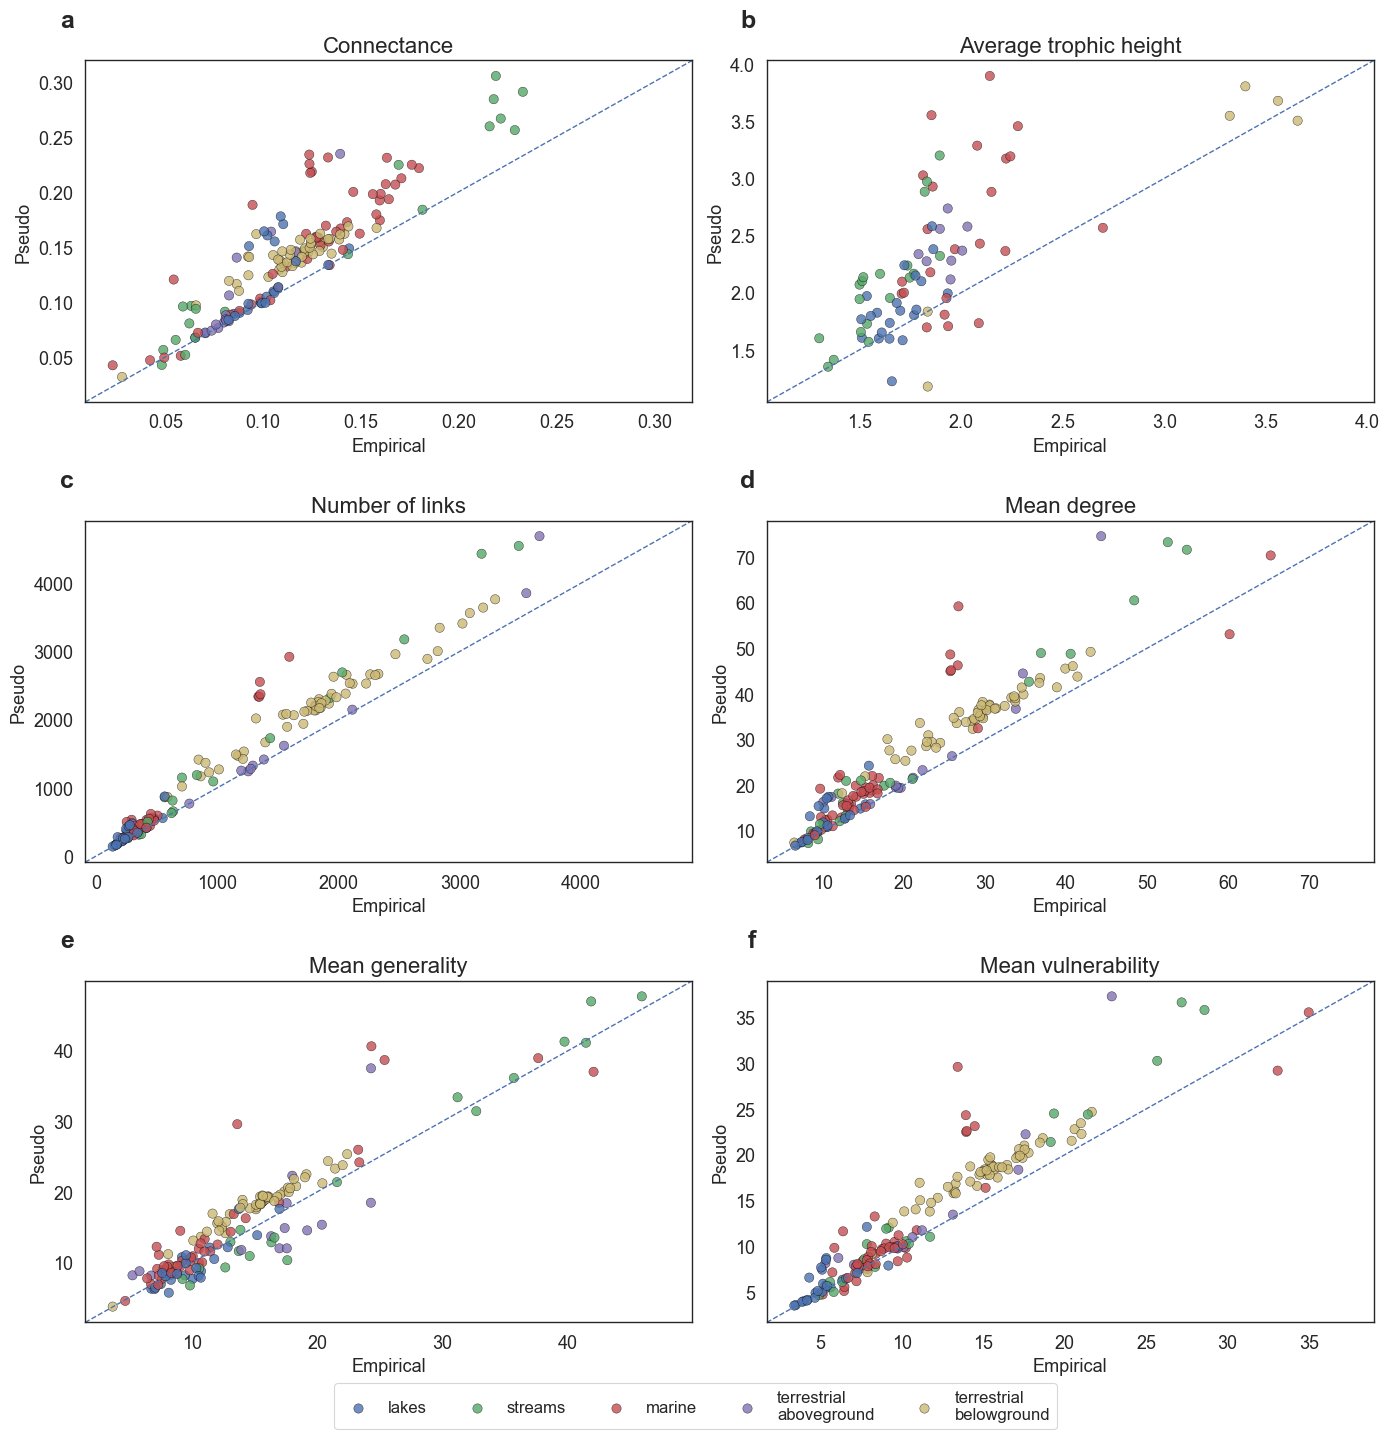

In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(context="paper", style="white")

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

NODES_THRESHOLD = 40
AGGREGATE_PER_FOODWEB = True  # recommended: average repeated experiments per food web
TROPHIC_LEVEL_MIN = 1.0
TROPHIC_LEVEL_MAX = 4.0
LINKS_Q_LOW = 0.00
LINKS_Q_HIGH = 0.98

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_palette = {
    "lakes": "#4C72B0",
    "streams": "#55A868",
    "marine": "#C44E52",
    "terrestrial aboveground": "#8172B3",
    "terrestrial belowground": "#CCB974",
}

ecosystem_labels = {
    "lakes": "lakes",
    "streams": "streams",
    "marine": "marine",
    "terrestrial aboveground": "terrestrial\naboveground",
    "terrestrial belowground": "terrestrial\nbelowground",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

# ============================================================
# HELPERS
# ============================================================
def extract_foodweb_name(filepath: str) -> str:
    """
    Extract foodweb name from:
    '.../XYZ_results_random_wlnm_dir_neg.csv' -> 'XYZ'
    """
    name = Path(filepath).name
    return name.split("_results_")[0]

def find_col(df: pd.DataFrame, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def load_all_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / "*_results_*.csv")))
    if not files:
        raise FileNotFoundError(f"No results CSVs found in: {results_dir}")

    dfs = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
            df["Foodweb"] = extract_foodweb_name(fp)
            df["SourceFile"] = Path(fp).name
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Skipping {fp}: {e}")

    if not dfs:
        raise RuntimeError("No readable result CSVs were loaded.")

    out = pd.concat(dfs, ignore_index=True)
    return out

def load_ecosystem_metadata(ecosystem_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(ecosystem_csv)

    foodweb_col = find_col(meta, ["Foodweb", "foodweb"])
    eco_col = find_col(meta, ["Ecosystem", "ecosystem", "EcosystemType", "ecosystem_type"])
    nodes_col = find_col(meta, ["Nodes", "nodes"])

    meta = meta.rename(columns={
        foodweb_col: "Foodweb",
        eco_col: "Ecosystem",
        nodes_col: "Nodes"
    })

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["Ecosystem"] = meta["Ecosystem"].astype(str)
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

    return meta[["Foodweb", "Ecosystem", "Nodes", "FW_KEY"]].drop_duplicates()

def safe_numeric_filter(df: pd.DataFrame) -> pd.DataFrame:
    # Keep only rows with valid core config fields if present
    needed = ["K", "TrainRatio"]
    for c in needed:
        if c in df.columns:
            df = df[pd.notna(df[c])]
    return df

def aggregate_foodweb_runs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate repeated experiments per food web.
    Empirical values are constant per web, pseudo/TSS/TPR may vary by run.
    We average all numeric columns per food web.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    grouped = df.groupby("Foodweb", as_index=False)[numeric_cols].mean()

    # Recover ecosystem
    eco_map = df[["Foodweb", "Ecosystem"]].drop_duplicates()
    grouped = grouped.merge(eco_map, on="Foodweb", how="left")

    # Reorder
    cols = ["Foodweb", "Ecosystem"] + [c for c in grouped.columns if c not in ("Foodweb", "Ecosystem")]
    grouped = grouped[cols]
    return grouped

def add_delta_columns(df: pd.DataFrame) -> pd.DataFrame:
    pairs = [
        ("Links", "EmpiricalLinks", "PseudoLinks"),
        ("Connectance", "EmpiricalConnectance", "PseudoConnectance"),
        ("MeanTrophicLevel", "EmpiricalMeanTrophicLevel", "PseudoMeanTrophicLevel"),
        ("MeanDegree", "EmpiricalMeanDegree", "PseudoMeanDegree"),
        ("MeanGenerality", "EmpiricalMeanGenerality", "PseudoMeanGenerality"),
        ("MeanVulnerability", "EmpiricalMeanVulnerability", "PseudoMeanVulnerability"),
    ]
    for short, emp, pse in pairs:
        if emp in df.columns and pse in df.columns:
            df[f"Delta_{short}"] = df[pse] - df[emp]
    return df

def annotate_1to1(ax, x, y):
    vals = np.concatenate([x.values, y.values])
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return
    lo = np.nanmin(vals)
    hi = np.nanmax(vals)
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo -= pad
    hi += pad
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

# ============================================================
# LOAD + PREPARE DATA
# ============================================================
results = load_all_results(RESULTS_DIR)
meta = load_ecosystem_metadata(ECOSYSTEM_CSV)

results = safe_numeric_filter(results)
results["FW_KEY"] = results["Foodweb"].apply(normalize_fw_label)

# Apply nodes threshold
allowed_fw_keys = set(meta.loc[meta["Nodes"] > NODES_THRESHOLD, "FW_KEY"].dropna().unique())
results = results[results["FW_KEY"].isin(allowed_fw_keys)].copy()

if results.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# Remove rows with obviously broken empirical/pseudo fields
core_cols = [
    "EmpiricalConnectance", "PseudoConnectance",
    "EmpiricalLinks", "PseudoLinks",
    "EmpiricalMeanGenerality", "PseudoMeanGenerality",
    "EmpiricalMeanVulnerability", "PseudoMeanVulnerability",
    "PseudoTSS", "PseudoTPR"
]
existing_core = [c for c in core_cols if c in results.columns]
results = results.dropna(subset=existing_core)

# Merge ecosystem
results = results.merge(
    meta[["FW_KEY", "Ecosystem"]].drop_duplicates(),
    on="FW_KEY",
    how="left",
    suffixes=("", "_meta")
)

# If both ecosystem columns exist, keep the metadata one when needed
if "Ecosystem_meta" in results.columns:
    results["Ecosystem"] = results["Ecosystem"].fillna(results["Ecosystem_meta"])
    results = results.drop(columns=["Ecosystem_meta"])

# Aggregate per foodweb if desired
plot_df = aggregate_foodweb_runs(results) if AGGREGATE_PER_FOODWEB else results.copy()
plot_df = add_delta_columns(plot_df)

# Dynamic filter bounds for Number of Links panel
_links_vals = pd.concat(
    [plot_df["EmpiricalLinks"], plot_df["PseudoLinks"]],
    ignore_index=True
).dropna()

LINKS_MIN = float(_links_vals.quantile(LINKS_Q_LOW))
LINKS_MAX = float(_links_vals.quantile(LINKS_Q_HIGH))

# ============================================================
# FIGURE 5 — VERSION 1 (OVERALL EMPIRICAL VS PSEUDO)
# ============================================================
metric_specs = [
    ("EmpiricalConnectance",      "PseudoConnectance",      "Connectance"),
    ("EmpiricalMeanTrophicLevel", "PseudoMeanTrophicLevel", "Average trophic height"),
    ("EmpiricalLinks",            "PseudoLinks",            "Number of links"),
    ("EmpiricalMeanDegree",       "PseudoMeanDegree",       "Mean degree"),
    ("EmpiricalMeanGenerality",   "PseudoMeanGenerality",   "Mean generality"),
    ("EmpiricalMeanVulnerability","PseudoMeanVulnerability","Mean vulnerability"),
]

n_panels = len(metric_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).reshape(-1)

legend_handles = {}
legend_labels = {}

for ax, (emp_col, pse_col, title) in zip(axes, metric_specs):
    if emp_col not in plot_df.columns or pse_col not in plot_df.columns:
        ax.set_visible(False)
        continue

    panel_df = plot_df.dropna(subset=[emp_col, pse_col, "Ecosystem"]).copy()

    # --- Special filter only for trophic height panel ---
    if emp_col == "EmpiricalMeanTrophicLevel" and pse_col == "PseudoMeanTrophicLevel":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pse_col]) &
            panel_df[emp_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df[pse_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    # --- Special filter only for Number of Links panel ---
    if emp_col == "EmpiricalLinks" and pse_col == "PseudoLinks":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pse_col]) &
            panel_df[emp_col].between(LINKS_MIN, LINKS_MAX) &
            panel_df[pse_col].between(LINKS_MIN, LINKS_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    # keep ecosystem order consistent
    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    hue_order = present_ecosystems + extra_ecosystems

    sns.scatterplot(
        data=panel_df,
        x=emp_col,
        y=pse_col,
        hue="Ecosystem",
        hue_order=hue_order,
        palette=ecosystem_palette,
        ax=ax,
        alpha=0.8,
        s=45,
        edgecolor="black",
        linewidth=0.3,
        legend=False,
    )

    # collect one legend handle per ecosystem
    for eco in hue_order:
        if eco not in legend_handles:
            sub = panel_df[panel_df["Ecosystem"] == eco]
            if not sub.empty:
                handle = ax.scatter(
                    [], [],
                    color=ecosystem_palette.get(eco, "gray"),
                    edgecolor="black",
                    linewidth=0.3,
                    s=45,
                    alpha=0.8,
                    label=eco,
                )
                legend_handles[eco] = handle
                legend_labels[eco] = ecosystem_labels.get(eco, eco)

    annotate_1to1(ax, panel_df[emp_col], panel_df[pse_col])
    ax.set_xlabel("Empirical", fontsize=13)
    ax.set_ylabel("Pseudo", fontsize=13)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="both", labelsize=13)

    ax.annotate(
        panel_letters[axes.tolist().index(ax)],
        xy=(0, 1.05), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_specs), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    [legend_handles[eco] for eco in legend_handles],
    [legend_labels[eco] for eco in legend_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
    frameon=True,
    fontsize=12,
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

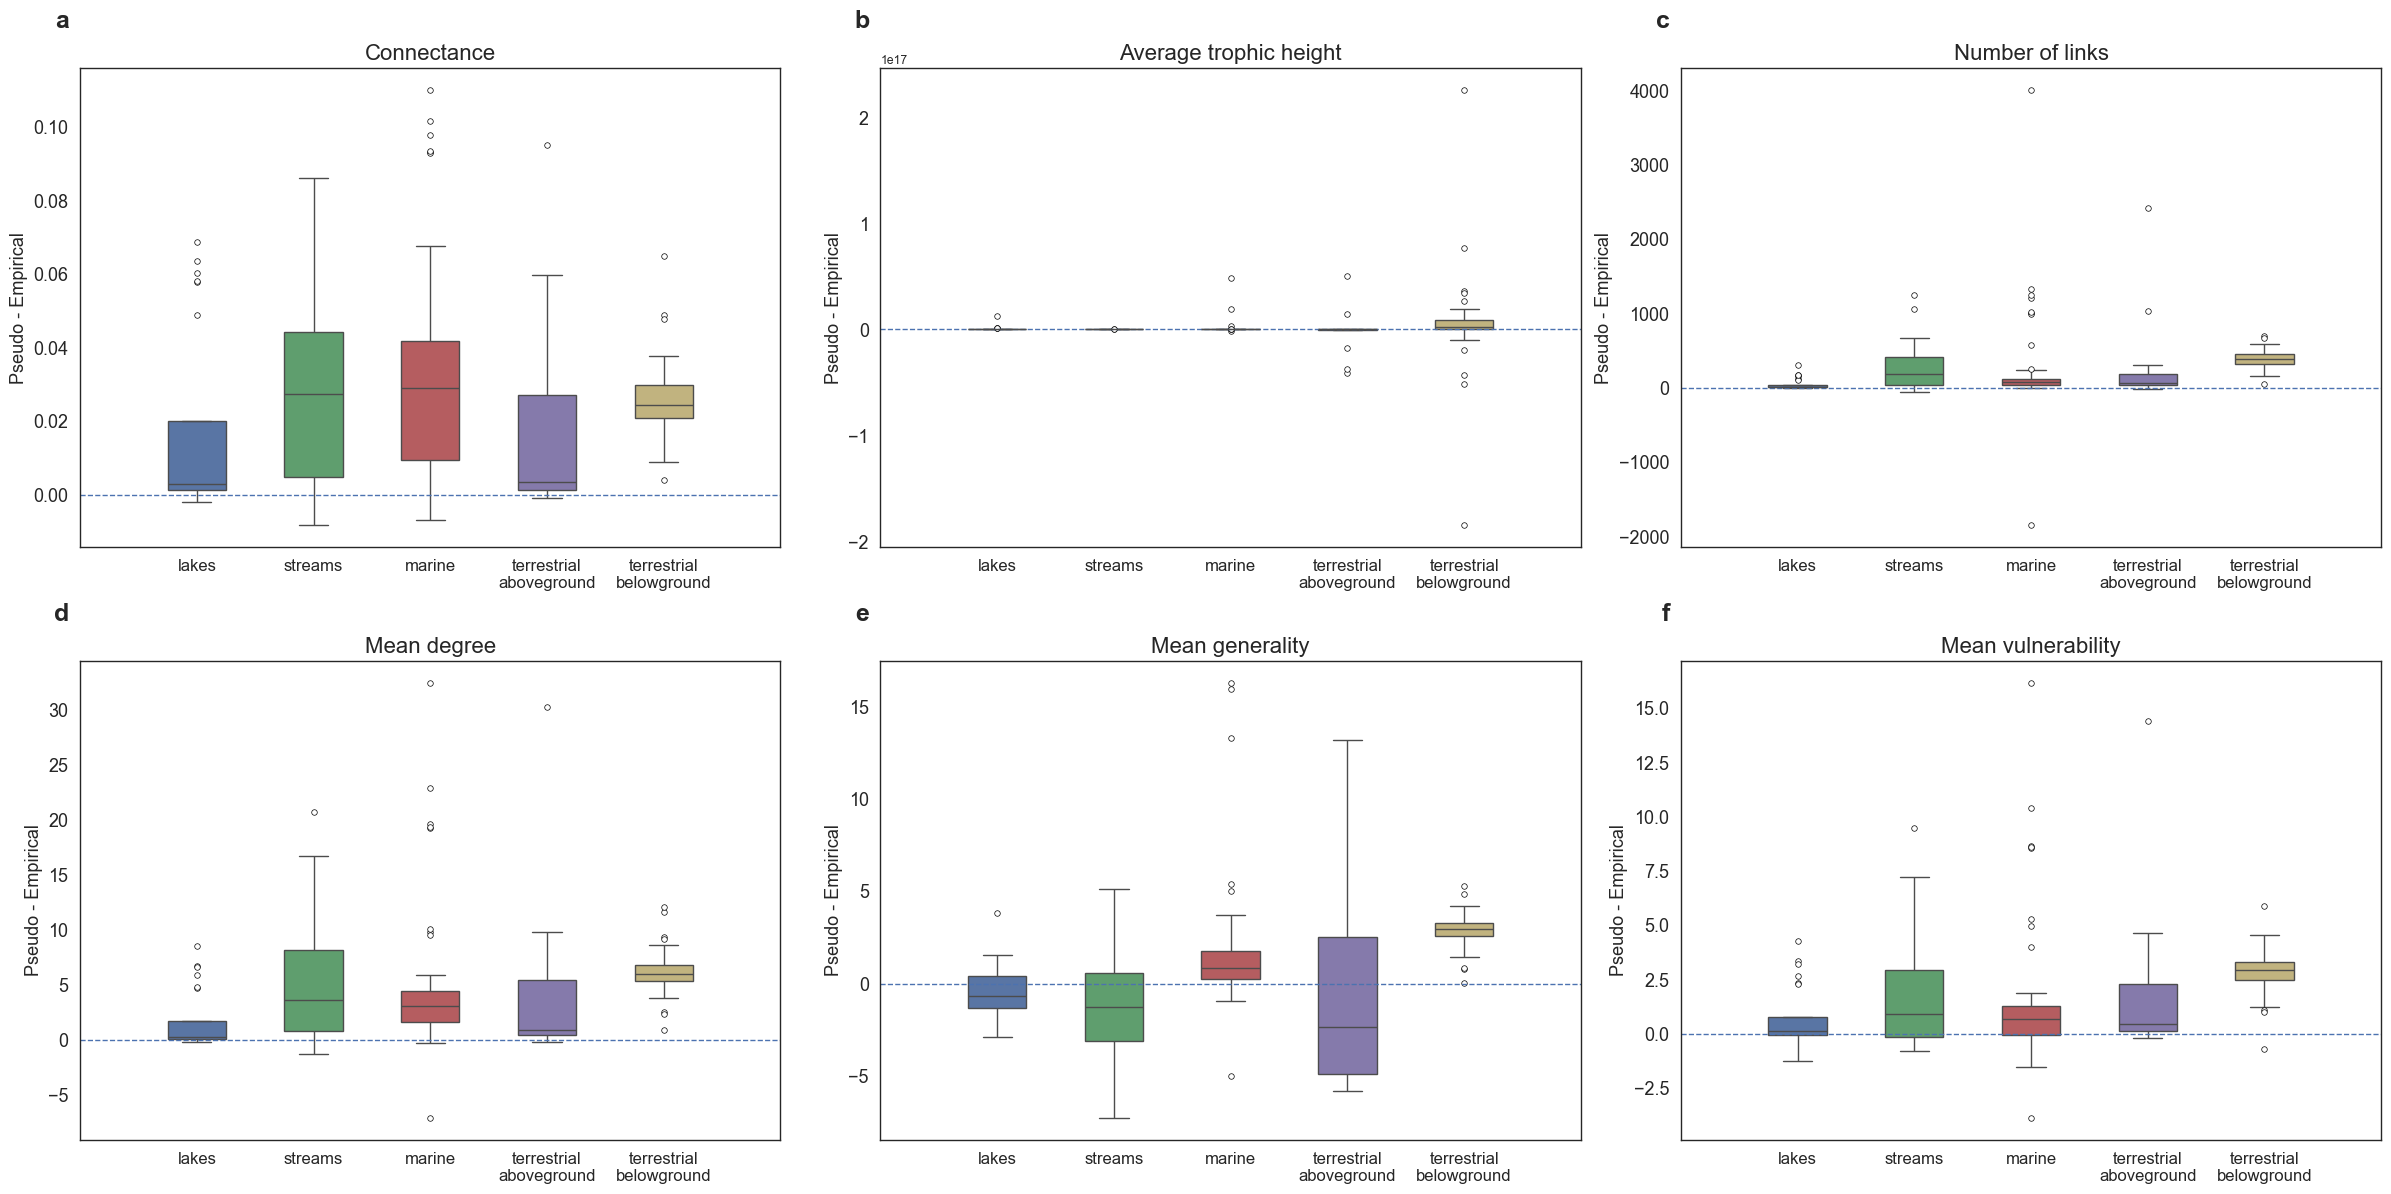

In [3]:
# ============================================================
# FIGURE 5 — VERSION 2 (BY ECOSYSTEM: DELTA = PSEUDO - EMPIRICAL)
# ============================================================
delta_specs = [
    ("Delta_Connectance", "Connectance"),
    ("Delta_MeanTrophicLevel", "Average trophic height"),
    ("Delta_Links", "Number of links"),
    ("Delta_MeanDegree", "Mean degree"),
    ("Delta_MeanGenerality", "Mean generality"),
    ("Delta_MeanVulnerability", "Mean vulnerability"),
]

fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

for ax, (col, title) in zip(axes, delta_specs):
    if col not in plot_df.columns:
        ax.set_visible(False)
        continue

    panel_df = plot_df.dropna(subset=[col, "Ecosystem"]).copy()

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    sns.boxplot(
        data=panel_df,
        x="Ecosystem",
        y=col,
        ax=ax,
        order=eco_order,
        palette=ecosystem_palette,
        hue="Ecosystem",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Pseudo - Empirical", fontsize=13)
    ax.set_xlim(-1, len(eco_order) - 1 + 1)
    ax.tick_params(axis="both", labelsize=13)

    ax.set_xticks(range(len(eco_order)))
    ax.set_xticklabels([ecosystem_labels.get(eco, eco) for eco in eco_order], rotation=0, fontsize=12)

    ax.annotate(
        panel_letters[axes.tolist().index(ax)],
        xy=(0, 1.05), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

fig.tight_layout()

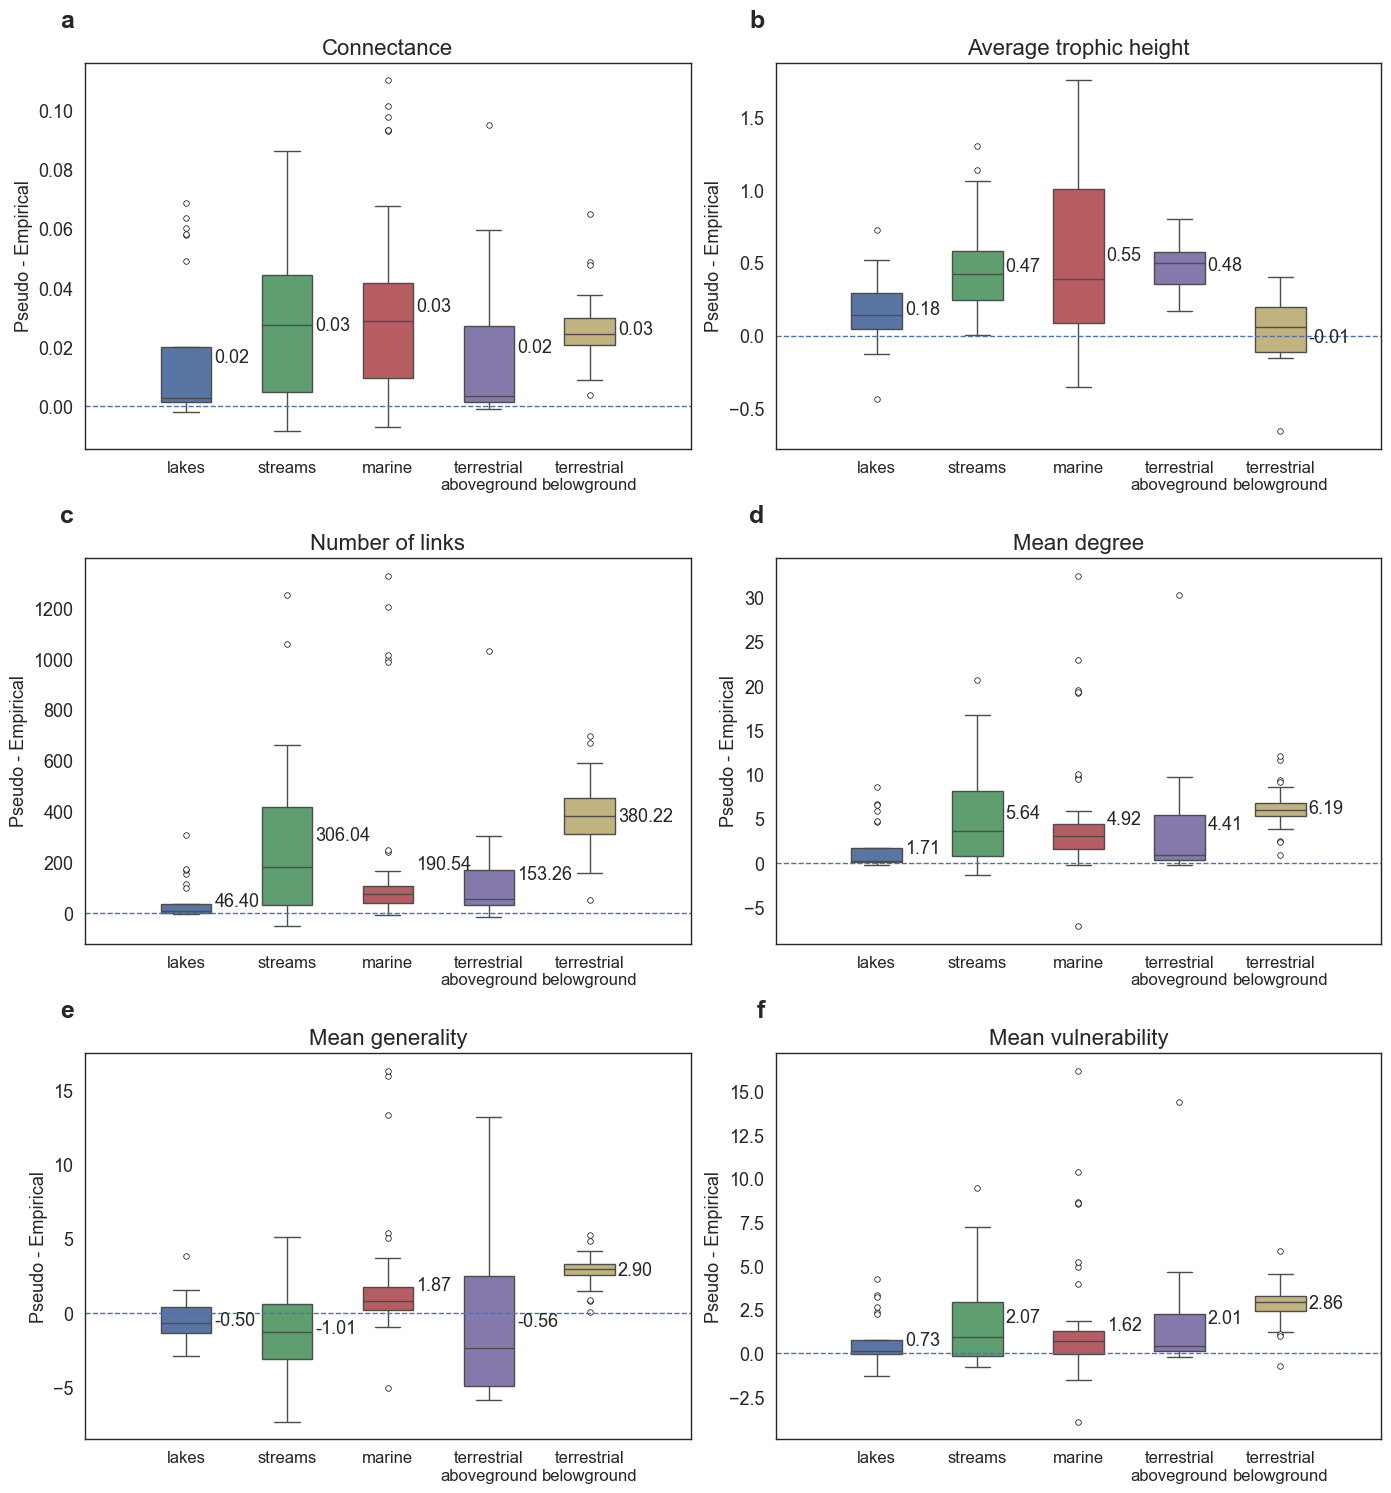

In [4]:
# ============================================================
# FIGURE 5 — VERSION 2 (BY ECOSYSTEM: DELTA = PSEUDO - EMPIRICAL)
# ============================================================
delta_specs = [
    ("Delta_Connectance", "Connectance"),
    ("Delta_MeanTrophicLevel", "Average trophic height"),
    ("Delta_Links", "Number of links"),
    ("Delta_MeanDegree", "Mean degree"),
    ("Delta_MeanGenerality", "Mean generality"),
    ("Delta_MeanVulnerability", "Mean vulnerability"),
]

n_panels = len(delta_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (col, title) in zip(axes, delta_specs):
    if col not in plot_df.columns:
        ax.set_visible(False)
        continue

    panel_df = plot_df.dropna(subset=[col, "Ecosystem"]).copy()

    # --- Special filter only for trophic height delta panel ---
    if col == "Delta_MeanTrophicLevel":
        panel_df = panel_df[
            np.isfinite(panel_df["EmpiricalMeanTrophicLevel"]) &
            np.isfinite(panel_df["PseudoMeanTrophicLevel"]) &
            panel_df["EmpiricalMeanTrophicLevel"].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df["PseudoMeanTrophicLevel"].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    # --- Special filter only for number-of-links delta panel ---
    if col == "Delta_Links":
        panel_df = panel_df[
            np.isfinite(panel_df["EmpiricalLinks"]) &
            np.isfinite(panel_df["PseudoLinks"]) &
            panel_df["EmpiricalLinks"].between(LINKS_MIN, LINKS_MAX) &
            panel_df["PseudoLinks"].between(LINKS_MIN, LINKS_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    sns.boxplot(
        data=panel_df,
        x="Ecosystem",
        y=col,
        ax=ax,
        order=eco_order,
        palette=ecosystem_palette,
        hue="Ecosystem",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
    )

    # Annotate mean delta per ecosystem
    for j, eco in enumerate(eco_order):
        vals = panel_df.loc[panel_df["Ecosystem"] == eco, col].dropna()
        if vals.empty:
            continue

        stat = vals.mean()   # recommended for boxplots with possible outliers
        ax.text(
            j + 0.28,          # slightly to the right of each box
            stat,
            f"{stat:.2f}",
            ha="left",
            va="center",
            fontsize=13,
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Pseudo - Empirical", fontsize=13)
    ax.set_xlim(-1, len(eco_order) - 1 + 1)
    ax.tick_params(axis="both", labelsize=13)

    ax.set_xticks(range(len(eco_order)))
    ax.set_xticklabels([ecosystem_labels.get(eco, eco) for eco in eco_order], rotation=0, fontsize=12)

    ax.annotate(
        panel_letters[axes.tolist().index(ax)],
        xy=(0, 1.05), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(delta_specs), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()

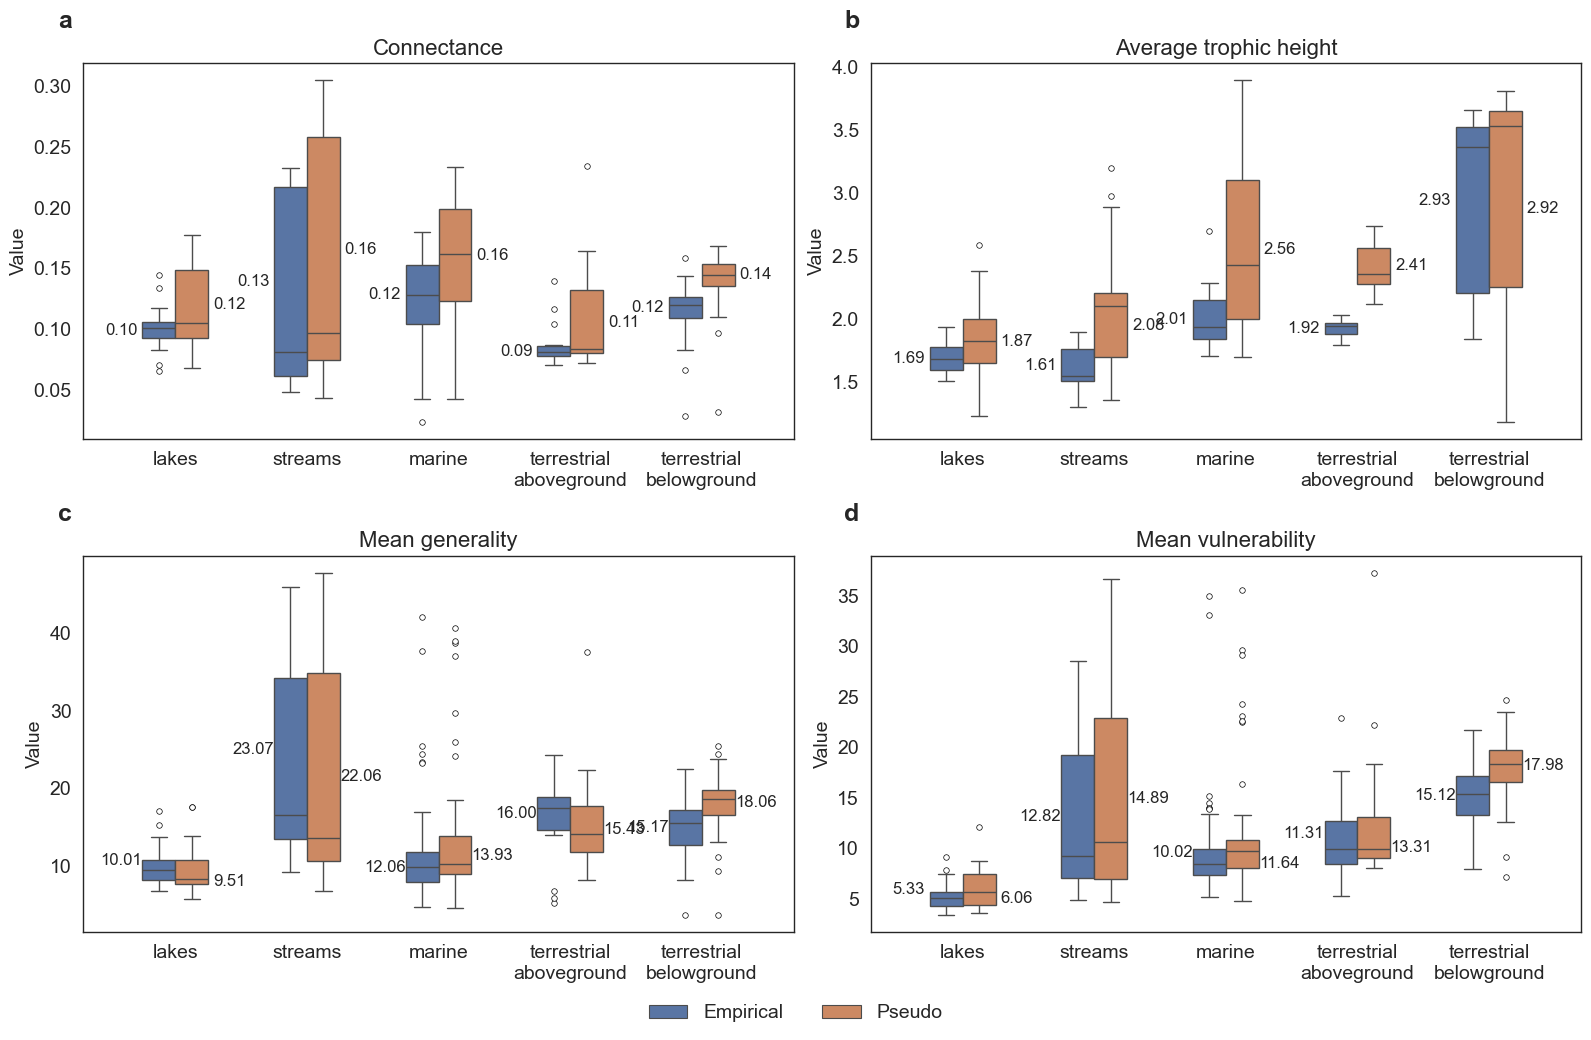

In [5]:
# ============================================================
# FIGURE 5 — VERSION 3
# BY ECOSYSTEM: EMPIRICAL vs PSEUDO SIDE BY SIDE
# ============================================================
paired_specs = [
    ("EmpiricalConnectance",       "PseudoConnectance",       "Connectance"),
    ("EmpiricalMeanTrophicLevel",  "PseudoMeanTrophicLevel",  "Average trophic height"),
    ("EmpiricalMeanGenerality",    "PseudoMeanGenerality",    "Mean generality"),
    ("EmpiricalMeanVulnerability", "PseudoMeanVulnerability", "Mean vulnerability"),
]

type_palette = {
    "Empirical": "#4C72B0",
    "Pseudo": "#DD8452",
}

type_offset = {
    "Empirical": -0.41,
    "Pseudo": 0.41,
}

n_panels = len(paired_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.array(axes).reshape(-1)

legend_handles, legend_labels = None, None

for idx, (ax, (emp_col, pseudo_col, title)) in enumerate(zip(axes, paired_specs)):
    required_cols = [emp_col, pseudo_col, "Ecosystem"]
    if not all(c in plot_df.columns for c in required_cols):
        ax.set_visible(False)
        continue

    panel_df = plot_df.dropna(subset=required_cols).copy()

    # --- Special filter only for trophic height panel ---
    if title == "Average trophic height":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pseudo_col]) &
            panel_df[emp_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df[pseudo_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    # --- Special filter only for number-of-links panel ---
    if title == "Number of links":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pseudo_col]) &
            panel_df[emp_col].between(LINKS_MIN, LINKS_MAX) &
            panel_df[pseudo_col].between(LINKS_MIN, LINKS_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    # Convert wide -> long for side-by-side boxplots
    long_df = panel_df.melt(
        id_vars=["Ecosystem"],
        value_vars=[emp_col, pseudo_col],
        var_name="NetworkType",
        value_name="Value",
    )

    long_df["NetworkType"] = long_df["NetworkType"].map({
        emp_col: "Empirical",
        pseudo_col: "Pseudo",
    })

    sns.boxplot(
        data=long_df,
        x="Ecosystem",
        y="Value",
        hue="NetworkType",
        order=eco_order,
        hue_order=["Empirical", "Pseudo"],
        palette=type_palette,
        ax=ax,
        width=0.5,
        dodge=True,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
    )

    # Save legend only once, then remove per-axis legends
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Annotate mean value for each group, but place text at IQR center
    y_min, y_max = ax.get_ylim()
    separation_threshold = 0.03 * (y_max - y_min)
    extra_offset = 0.05 * (y_max - y_min)

    for j, eco in enumerate(eco_order):
        emp_vals = long_df.loc[
            (long_df["Ecosystem"] == eco) &
            (long_df["NetworkType"] == "Empirical"),
            "Value"
        ].dropna()

        pseudo_vals = long_df.loc[
            (long_df["Ecosystem"] == eco) &
            (long_df["NetworkType"] == "Pseudo"),
            "Value"
        ].dropna()

        emp_mean = emp_vals.mean() if not emp_vals.empty else np.nan
        pseudo_mean = pseudo_vals.mean() if not pseudo_vals.empty else np.nan

        # IQR centers
        emp_q1 = emp_vals.quantile(0.25) if not emp_vals.empty else np.nan
        emp_q3 = emp_vals.quantile(0.75) if not emp_vals.empty else np.nan
        pseudo_q1 = pseudo_vals.quantile(0.25) if not pseudo_vals.empty else np.nan
        pseudo_q3 = pseudo_vals.quantile(0.75) if not pseudo_vals.empty else np.nan

        emp_y = (emp_q1 + emp_q3) / 2 if np.isfinite(emp_q1) and np.isfinite(emp_q3) else np.nan
        pseudo_y = (pseudo_q1 + pseudo_q3) / 2 if np.isfinite(pseudo_q1) and np.isfinite(pseudo_q3) else np.nan

        # If the two label positions are too close, separate them slightly
        if np.isfinite(emp_y) and np.isfinite(pseudo_y):
            if abs(emp_y - pseudo_y) < separation_threshold:
                emp_y = emp_y + extra_offset / 2
                pseudo_y = pseudo_y - extra_offset / 2

        if np.isfinite(emp_mean) and np.isfinite(emp_y):
            ax.text(
                j + type_offset["Empirical"],
                emp_y,
                f"{emp_mean:.2f}",
                ha="center",
                va="center",
                fontsize=12,
            )

        if np.isfinite(pseudo_mean) and np.isfinite(pseudo_y):
            ax.text(
                j + type_offset["Pseudo"],
                pseudo_y,
                f"{pseudo_mean:.2f}",
                ha="center",
                va="center",
                fontsize=12,
            )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Value", fontsize=14)
    ax.set_xlim(-0.7, len(eco_order) - 1 + 0.7)
    ax.tick_params(axis="both", labelsize=14)

    ax.set_xticks(range(len(eco_order)))
    ax.set_xticklabels(
        [ecosystem_labels.get(eco, eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05), xycoords="axes fraction",
        xytext=(-8, 8), textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(len(paired_specs), len(axes)):
    axes[j].set_visible(False)

# Shared legend
if legend_handles is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, 0.01),
    )

fig.tight_layout()

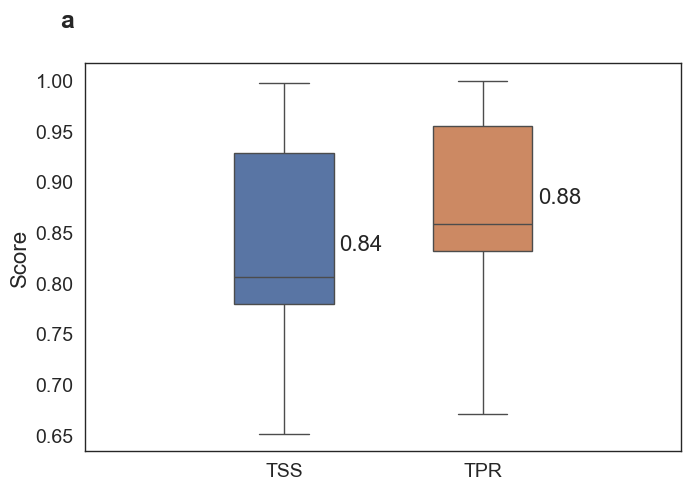

In [6]:
# ============================================================
# TSS / TPR — VERSION 1 (ALL RESULTS, SINGLE PANEL)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

tss_tpr_df = plot_df[["PseudoTSS", "PseudoTPR"]].rename(
    columns={
        "PseudoTSS": "TSS",
        "PseudoTPR": "TPR"
    }
).melt(var_name="Metric", value_name="Score")

sns.boxplot(
    data=tss_tpr_df,
    x="Metric",
    y="Score",
    ax=ax,
    palette={
        "TSS": "#4C72B0",   # blue
        "TPR": "#DD8452"    # orange
    },
    hue="Metric",
    legend=False,
    width=0.5,
    flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
)

# Annotate mean per box
for j, version_name in enumerate(["TSS", "TPR"]):
    vals = tss_tpr_df.loc[tss_tpr_df["Metric"] == version_name, "Score"].dropna()
    if vals.empty:
        continue

    stat = vals.mean()
    ax.text(
        j + 0.28,
        stat,
        f"{stat:.2f}",
        ha="left",
        va="center",
        fontsize=16,
    )

ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=16)
ax.tick_params(axis="y", labelleft=True, labelsize=14)
ax.set_xlim(-1, len(["TSS", "TPR"]) - 1 + 1)
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.annotate(
    "a",
    xy=(0, 1.05), xycoords="axes fraction",
    xytext=(-8, 8), textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=18,
    fontweight="bold",
    annotation_clip=False,
)
fig.tight_layout()

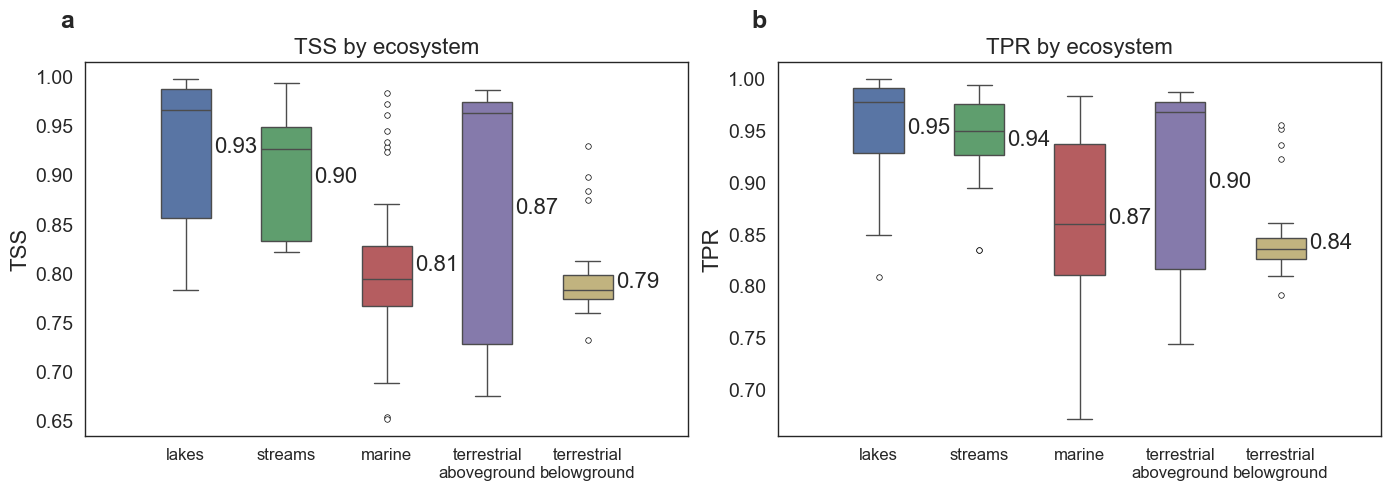

In [7]:
# ============================================================
# TSS / TPR — VERSION 2 (BY ECOSYSTEM)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_palette = {
    "lakes": "#4C72B0",
    "streams": "#55A868",
    "marine": "#C44E52",
    "terrestrial aboveground": "#8172B3",
    "terrestrial belowground": "#CCB974",
}

ecosystem_labels = {
    "lakes": "lakes",
    "streams": "streams",
    "marine": "marine",
    "terrestrial aboveground": "terrestrial\naboveground",
    "terrestrial belowground": "terrestrial\nbelowground",
}

def present_order(df, metric_col, preferred_order):
    present = (
        df.loc[df[metric_col].notna(), "Ecosystem"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    ordered_present = [eco for eco in preferred_order if eco in present]
    extras = [eco for eco in present if eco not in preferred_order]
    return ordered_present + extras

# ----------------------------
# TSS panel
# ----------------------------
tss_order = present_order(plot_df, "PseudoTSS", base_ecosystem_order)

sns.boxplot(
    data=plot_df.dropna(subset=["PseudoTSS", "Ecosystem"]),
    x="Ecosystem",
    y="PseudoTSS",
    ax=axes[0],
    order=tss_order,
    palette=ecosystem_palette,
    hue="Ecosystem",
    legend=False,
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
        "linestyle": "none",
    }
)

for j, eco in enumerate(tss_order):
    vals = plot_df.loc[plot_df["Ecosystem"] == eco, "PseudoTSS"].dropna()
    if vals.empty:
        continue

    stat = vals.mean()
    axes[0].text(
        j + 0.28,
        stat,
        f"{stat:.2f}",
        ha="left",
        va="center",
        fontsize=16,
    )

axes[0].set_title("TSS by ecosystem", fontsize=16)
axes[0].set_xlabel("")
axes[0].set_ylabel("TSS", fontsize=16)
axes[0].tick_params(axis="y", labelleft=True, labelsize=14)
axes[0].set_xlim(-1, len(tss_order) - 1 + 1)
axes[0].set_xticks(range(len(tss_order)))
axes[0].set_xticklabels([ecosystem_labels.get(eco, eco) for eco in tss_order], fontsize=12)
axes[0].tick_params(axis="x", rotation=0)
axes[0].annotate(
    "a",
    xy=(0, 1.05), xycoords="axes fraction",
    xytext=(-8, 8), textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=18,
    fontweight="bold",
    annotation_clip=False,
)

# ----------------------------
# TPR panel
# ----------------------------
tpr_order = present_order(plot_df, "PseudoTPR", base_ecosystem_order)

sns.boxplot(
    data=plot_df.dropna(subset=["PseudoTPR", "Ecosystem"]),
    x="Ecosystem",
    y="PseudoTPR",
    ax=axes[1],
    order=tpr_order,
    palette=ecosystem_palette,
    hue="Ecosystem",
    legend=False,
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
        "linestyle": "none",
    }
)

for j, eco in enumerate(tpr_order):
    vals = plot_df.loc[plot_df["Ecosystem"] == eco, "PseudoTPR"].dropna()
    if vals.empty:
        continue

    stat = vals.mean()
    axes[1].text(
        j + 0.28,
        stat,
        f"{stat:.2f}",
        ha="left",
        va="center",
        fontsize=16,
    )

axes[1].set_title("TPR by ecosystem", fontsize=16)
axes[1].set_xlabel("")
axes[1].set_ylabel("TPR", fontsize=16)
axes[1].tick_params(axis="y", labelleft=True, labelsize=14)
axes[1].set_xlim(-1, len(tpr_order) - 1 + 1)
axes[1].set_xticks(range(len(tpr_order)))
axes[1].set_xticklabels([ecosystem_labels.get(eco, eco) for eco in tpr_order], fontsize=12)
axes[1].tick_params(axis="x", rotation=0)
axes[1].annotate(
    "b",
    xy=(0, 1.05), xycoords="axes fraction",
    xytext=(-8, 8), textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=18,
    fontweight="bold",
    annotation_clip=False,
)

fig.tight_layout()